# Notebook 09 — False Positive Stress Test (BENIGN Baseline)

## Objective
Validate SOC signal candidates by quantifying **baseline noise** in BENIGN traffic.

This notebook answers:
1) What does "normal" look like for key signal features?
2) Which naive thresholds would generate high false positives?
3) Which signals are operationally usable?

---

## Inputs (from Notebook 08)
- `outputs/tables/08_signal_candidate_mapping.csv`

---

## Outputs
- `outputs/tables/09_baseline_quantiles.csv`
- `outputs/tables/09_false_positive_rates.csv`

No ML. Detection engineering only.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


In [2]:
import sys
from pathlib import Path

PHASE_ROOT = Path(r"D:\Projects\CICIDS-2017\03-security-integration\cicids-2017\phase-3.5-soc-detection").resolve()

# fallback: try to find phase folder from cwd upward
if not PHASE_ROOT.exists():
    cwd = Path.cwd().resolve()
    for p in [cwd] + list(cwd.parents):
        candidate = p / "03-security-integration" / "cicids-2017" / "phase-3.5-soc-detection"
        if candidate.exists():
            PHASE_ROOT = candidate.resolve()
            break

if not PHASE_ROOT.exists():
    raise RuntimeError("Could not locate phase-3.5-soc-detection folder.")

if str(PHASE_ROOT) not in sys.path:
    sys.path.insert(0, str(PHASE_ROOT))

print("PHASE_ROOT:", PHASE_ROOT)


PHASE_ROOT: D:\Projects\CICIDS-2017\03-security-integration\cicids-2017\phase-3.5-soc-detection


In [3]:
OUTPUT_DIR = PHASE_ROOT / "outputs"
OUTPUT_TABLES = OUTPUT_DIR / "tables"
OUTPUT_FIGS = OUTPUT_DIR / "figures"

OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGS.mkdir(parents=True, exist_ok=True)

OUTPUT_TABLES, OUTPUT_FIGS


(WindowsPath('D:/Projects/CICIDS-2017/03-security-integration/cicids-2017/phase-3.5-soc-detection/outputs/tables'),
 WindowsPath('D:/Projects/CICIDS-2017/03-security-integration/cicids-2017/phase-3.5-soc-detection/outputs/figures'))

In [5]:
from utils.cicids_loader import load_cicids_multi
from utils.sanitize import sanitize_df


## Method

### Step A — Baseline Quantiles
Compute quantiles for key features using **BENIGN-only** traffic.

We compute:
- median (q50)
- q90
- q95
- q99
- q99.9

### Step B — False Positive Rate (FPR)
For each feature, treat thresholds as:
- threshold = BENIGN q95
- threshold = BENIGN q99
- threshold = BENIGN q99.9

Compute:
FPR = fraction of BENIGN flows exceeding threshold.

High FPR = alert is operationally noisy (analyst fatigue).


In [6]:
BASELINE_FILES = [
    "Monday-WorkingHours.pcap_ISCX.csv"
]

df_base = load_cicids_multi(
    files=BASELINE_FILES,
    sample_per_file=150000,   # large enough baseline without blowing RAM
    random_state=42
)

df_base = sanitize_df(df_base)
df_base = df_base[df_base["Label"] == "BENIGN"].copy()

df_base.shape


(145144, 79)

In [18]:
print("BASELINE_FILES:", BASELINE_FILES)
print("Sample per file:", 150000)
print("Baseline shape:", df_base.shape)
print(df_base["Label"].value_counts().head())


BASELINE_FILES: ['Monday-WorkingHours.pcap_ISCX.csv']
Sample per file: 150000
Baseline shape: (145144, 79)
Label
BENIGN    145144
Name: count, dtype: int64


In [8]:
mapping_path = OUTPUT_TABLES / "08_signal_candidate_mapping.csv"
if not mapping_path.exists():
    raise FileNotFoundError(f"Missing mapping table: {mapping_path} (Run Notebook 08 first).")

signal_map = pd.read_csv(mapping_path)
signal_map


,soc_alert,expected_attack_labels,candidate_features,why_it_works,main_false_positive_risk
0,Reconnaissance / Port Scan,PortScan,"Flow Pkts/s, Tot Fwd Pkts, Tot Bwd Pkts, SYN F...",Scanning produces many small flows and abnorma...,"IT scanning, vulnerability scanners, monitorin..."
1,DoS / DDoS Flood Behavior,"DDoS, DoS Hulk, DoS GoldenEye","Flow Bytes/s, Flow Pkts/s, Packet Length Mean,...",Flooding creates rate spikes and unusual distr...,"Legitimate traffic surges, backups, high-traff..."
2,Brute Force / Repeated Attempts (Network Proxy),"FTP-Patator, SSH-Patator","Flow Duration, Flow IAT Mean, Tot Fwd Pkts, Ac...",Repeated access attempts tend to produce repea...,"Automation scripts, misconfigured clients, loa..."
3,Web Attack / Suspicious Session Behavior (Proxy),"Web Attack – Brute Force, Web Attack – XSS","Flow Duration, Fwd Pkt Len Mean, Flow IAT Std,...",Web attacks may affect session timing and dire...,"Normal browsing bursts, content-heavy pages, A..."
4,Large Outbound Transfer (Exfil Proxy),"Infiltration (proxy), Exfil-like behavior","TotLen Fwd Pkts, Flow Bytes/s, Down/Up Ratio, ...",High forward payload volume and asymmetry can ...,"File uploads, sync tools, legitimate bulk data..."
5,Protocol / Infrastructure Anomaly (Proxy),Various,"SYN Flag Cnt, RST Flag Cnt, ACK Flag Cnt, PSH ...",Protocol manipulation or unstable sessions dis...,"Retransmissions, packet loss, unstable networks"


In [9]:
def parse_features(feature_string: str):
    parts = [x.strip() for x in str(feature_string).split(",")]
    return [p for p in parts if p]

mapped_features = []
for s in signal_map["candidate_features"].tolist():
    mapped_features.extend(parse_features(s))

mapped_features = sorted(set(mapped_features))
len(mapped_features), mapped_features[:20]


(19,
 ['ACK Flag Cnt',
  'Active Mean',
  'Bwd Pkt Len Mean',
  'Down/Up Ratio',
  'Flow Bytes/s',
  'Flow Duration',
  'Flow IAT Mean',
  'Flow IAT Std',
  'Flow Pkts/s',
  'Fwd Pkt Len Mean',
  'PSH Flag Cnt',
  'Packet Length Mean',
  'Packet Length Std',
  'RST Flag Cnt',
  'SYN Flag Cnt',
  'Tot Bwd Pkts',
  'Tot Fwd Pkts',
  'TotLen Fwd Pkts',
  'URG Flag Cnt'])

In [10]:
existing_features = [f for f in mapped_features if f in df_base.columns]
missing_features = [f for f in mapped_features if f not in df_base.columns]

print("Existing features:", len(existing_features))
print("Missing features:", len(missing_features))

missing_features[:20]


Existing features: 8
Missing features: 11


['ACK Flag Cnt',
 'Bwd Pkt Len Mean',
 'Flow Pkts/s',
 'Fwd Pkt Len Mean',
 'PSH Flag Cnt',
 'RST Flag Cnt',
 'SYN Flag Cnt',
 'Tot Bwd Pkts',
 'Tot Fwd Pkts',
 'TotLen Fwd Pkts',
 'URG Flag Cnt']

## Baseline Quantiles (BENIGN)

These quantiles define what "normal" looks like.
They are required for any threshold-based alert design.


In [11]:
quantiles = [0.50, 0.90, 0.95, 0.99, 0.999]

rows = []
for f in existing_features:
    series = pd.to_numeric(df_base[f], errors="coerce").dropna()
    if series.empty:
        continue

    qvals = series.quantile(quantiles).to_dict()

    row = {"feature": f}
    for q, v in qvals.items():
        # q0.999 -> q99.9 formatting
        label = f"q{q*100:.1f}".replace(".0", "")
        row[label] = float(v)
    rows.append(row)

baseline_q_df = pd.DataFrame(rows).sort_values("feature").reset_index(drop=True)
baseline_q_df.head(15)


,feature,q50,q90,q95,q99,q99.9
0,Active Mean,0.000000,6.928301e+04,2.160679e+05,1.391086e+06,8.056576e+06
1,Down/Up Ratio,1.000000,1.000000e+00,1.000000e+00,2.000000e+00,4.000000e+00
2,Flow Bytes/s,5261.352404,1.613390e+06,3.660878e+06,1.233333e+07,1.220870e+08
3,Flow Duration,31867.500000,4.665341e+07,1.048421e+08,1.177713e+08,1.197674e+08
4,Flow IAT Mean,12233.166667,1.999015e+06,3.713760e+06,2.499841e+07,6.406609e+07
5,Flow IAT Std,144.914918,3.812842e+06,5.005977e+06,3.794353e+07,6.484084e+07
6,Packet Length Mean,61.333333,2.792278e+02,3.928571e+02,8.898132e+02,1.280821e+03
7,Packet Length Std,30.124741,5.259492e+02,6.654640e+02,1.048796e+03,1.249288e+03


In [12]:
out_q = OUTPUT_TABLES / "09_baseline_quantiles.csv"
baseline_q_df.to_csv(out_q, index=False)
out_q


WindowsPath('D:/Projects/CICIDS-2017/03-security-integration/cicids-2017/phase-3.5-soc-detection/outputs/tables/09_baseline_quantiles.csv')

## False Positive Stress Test

We use BENIGN quantiles as naive alert thresholds, then estimate false positive rate.

Threshold levels tested:
- p95
- p99
- p99.9

This simulates: "if we alert above threshold, how many BENIGN flows trigger alerts?"


In [13]:
threshold_levels = {
    "p95": 0.95,
    "p99": 0.99,
    "p999": 0.999
}

fpr_rows = []

for f in existing_features:
    series = pd.to_numeric(df_base[f], errors="coerce").dropna()
    if series.empty:
        continue

    for name, q in threshold_levels.items():
        t = float(series.quantile(q))
        fpr = float((series > t).mean())

        fpr_rows.append({
            "feature": f,
            "threshold_type": name,
            "threshold_value": t,
            "false_positive_rate": fpr
        })

fpr_df = pd.DataFrame(fpr_rows)
fpr_df.sort_values(["threshold_type", "false_positive_rate"], ascending=[True, False]).head(20)


,feature,threshold_type,threshold_value,false_positive_rate
0,Active Mean,p95,2.160679e+05,0.050006
6,Flow Bytes/s,p95,3.660878e+06,0.050006
9,Flow Duration,p95,1.048421e+08,0.050006
12,Flow IAT Mean,p95,3.713760e+06,0.050006
15,Flow IAT Std,p95,5.005977e+06,0.050006
21,Packet Length Std,p95,6.654640e+02,0.050006
18,Packet Length Mean,p95,3.928571e+02,0.049999
3,Down/Up Ratio,p95,1.000000e+00,0.011816
1,Active Mean,p99,1.391086e+06,0.010004
10,Flow Duration,p99,1.177713e+08,0.010004


In [14]:
out_fpr = OUTPUT_TABLES / "09_false_positive_rates.csv"
fpr_df.to_csv(out_fpr, index=False)
out_fpr


WindowsPath('D:/Projects/CICIDS-2017/03-security-integration/cicids-2017/phase-3.5-soc-detection/outputs/tables/09_false_positive_rates.csv')

In [15]:
def categorize_fpr(x: float) -> str:
    # SOC intuition thresholds
    if x >= 0.05:
        return "HIGH_NOISE"
    if x >= 0.01:
        return "MEDIUM_NOISE"
    if x >= 0.001:
        return "LOW_NOISE"
    return "VERY_LOW_NOISE"

summary_p99 = (
    fpr_df[fpr_df["threshold_type"] == "p99"]
    .copy()
    .assign(operational_noise=lambda d: d["false_positive_rate"].apply(categorize_fpr))
    .sort_values("false_positive_rate", ascending=False)
)

summary_p99.head(25)


,feature,threshold_type,threshold_value,false_positive_rate,operational_noise
1,Active Mean,p99,1.391086e+06,0.010004,MEDIUM_NOISE
10,Flow Duration,p99,1.177713e+08,0.010004,MEDIUM_NOISE
13,Flow IAT Mean,p99,2.499841e+07,0.010004,MEDIUM_NOISE
16,Flow IAT Std,p99,3.794353e+07,0.010004,MEDIUM_NOISE
19,Packet Length Mean,p99,8.898132e+02,0.010004,MEDIUM_NOISE
22,Packet Length Std,p99,1.048796e+03,0.010004,MEDIUM_NOISE
7,Flow Bytes/s,p99,1.233333e+07,0.009818,LOW_NOISE
4,Down/Up Ratio,p99,2.000000e+00,0.004561,LOW_NOISE


In [16]:
top_noisy = summary_p99.head(12)
top_noisy


,feature,threshold_type,threshold_value,false_positive_rate,operational_noise
1,Active Mean,p99,1.391086e+06,0.010004,MEDIUM_NOISE
10,Flow Duration,p99,1.177713e+08,0.010004,MEDIUM_NOISE
13,Flow IAT Mean,p99,2.499841e+07,0.010004,MEDIUM_NOISE
16,Flow IAT Std,p99,3.794353e+07,0.010004,MEDIUM_NOISE
19,Packet Length Mean,p99,8.898132e+02,0.010004,MEDIUM_NOISE
22,Packet Length Std,p99,1.048796e+03,0.010004,MEDIUM_NOISE
7,Flow Bytes/s,p99,1.233333e+07,0.009818,LOW_NOISE
4,Down/Up Ratio,p99,2.000000e+00,0.004561,LOW_NOISE


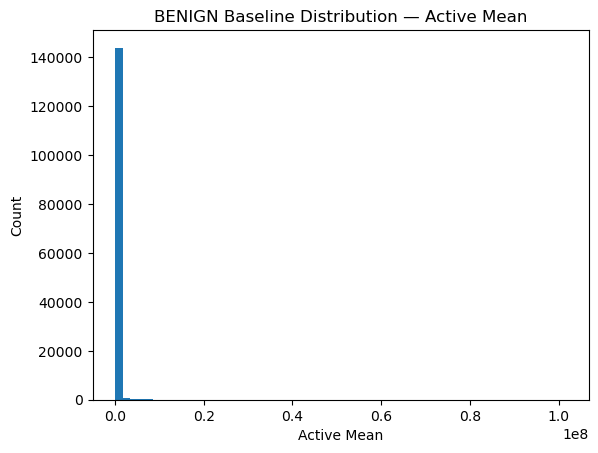

<Figure size 640x480 with 0 Axes>

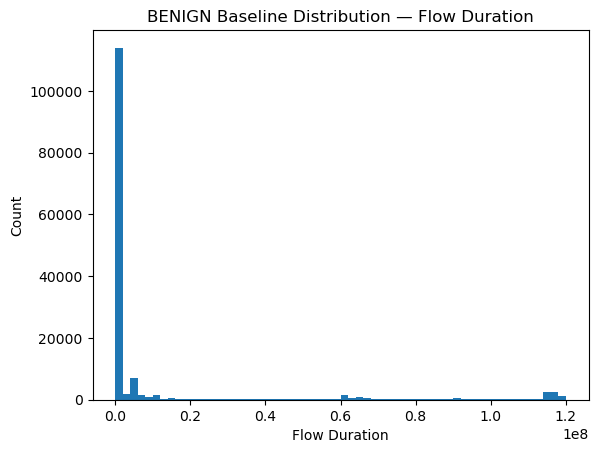

<Figure size 640x480 with 0 Axes>

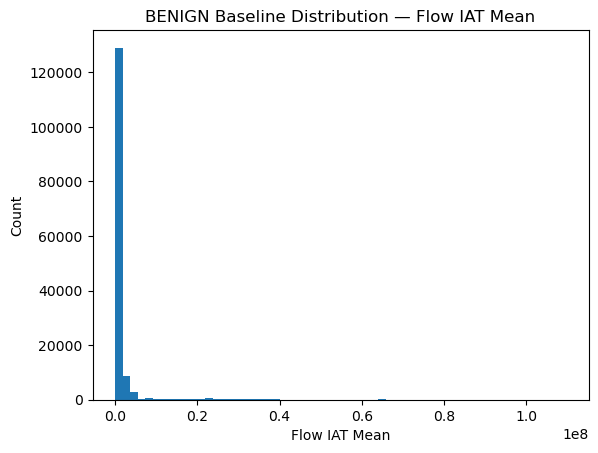

<Figure size 640x480 with 0 Axes>

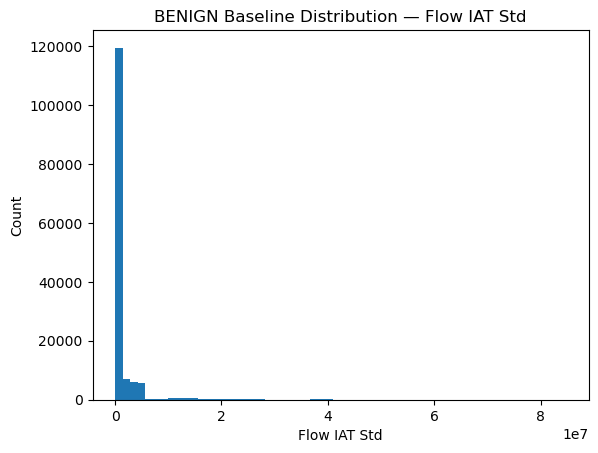

<Figure size 640x480 with 0 Axes>

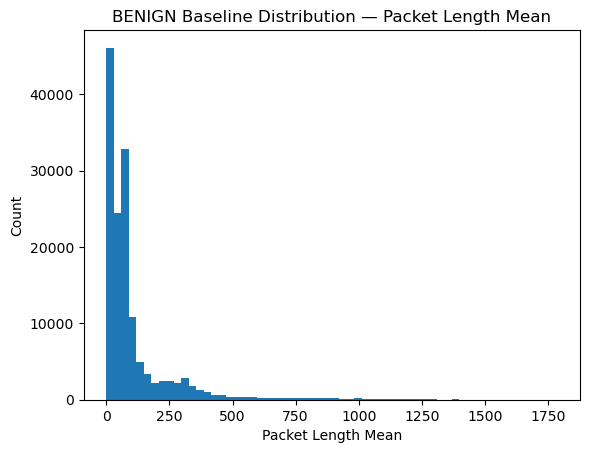

<Figure size 640x480 with 0 Axes>

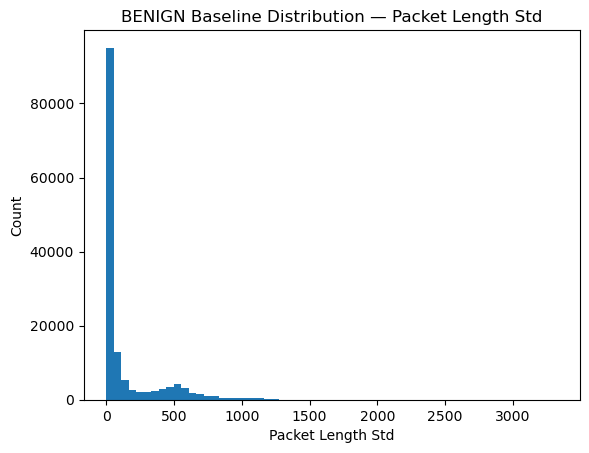

<Figure size 640x480 with 0 Axes>

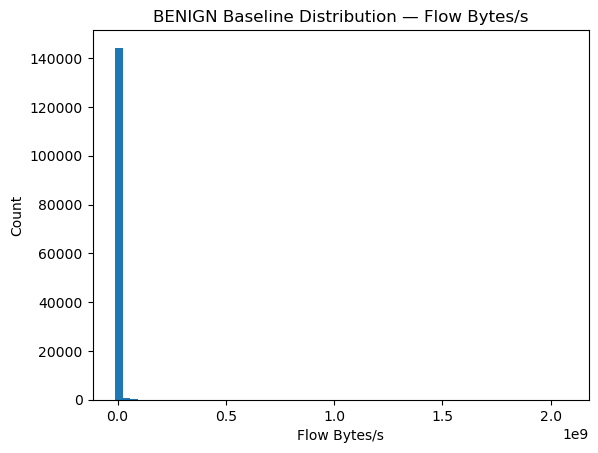

<Figure size 640x480 with 0 Axes>

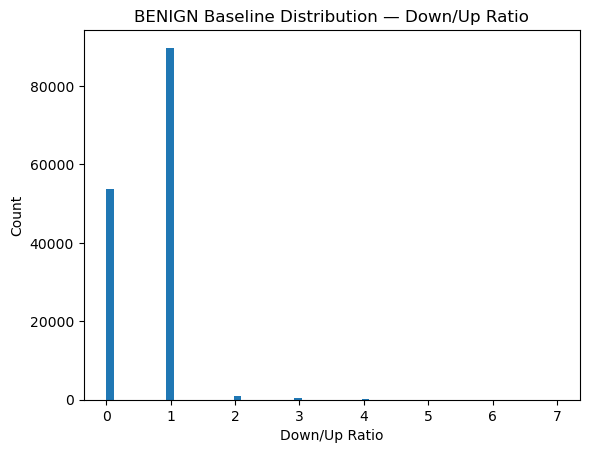

<Figure size 640x480 with 0 Axes>

In [19]:
top_features = top_noisy["feature"].tolist()

for f in top_features:
    s = pd.to_numeric(df_base[f], errors="coerce").dropna()
    if s.empty:
        continue

    plt.figure()
    plt.hist(s, bins=60)
    plt.title(f"BENIGN Baseline Distribution — {f}")
    plt.xlabel(f)
    plt.ylabel("Count")
    plt.show()
    out = OUTPUT_FIGS / f"09_baseline_hist_{f.replace('/', '_')}.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")



## Conclusion

### What we proved
- BENIGN traffic has strong baseline ranges for many telemetry features.
- Naive thresholds can generate massive noise for some features.
- Operational detections require context and correlation, not single-feature rules.

### Artifacts exported
- `09_baseline_quantiles.csv`
- `09_false_positive_rates.csv`

Next:
Notebook 10 — Context dependency and correlation (why single metrics fail).
